## **BAB 6. EXPLANATORY DATA ANALYSIS (EDA) II**

### Eksplorasi Data Awal (Pair Plot)

Kita akan memulai eksplorasi data dengan membuat _dummy DataFrame_ yang berisi informasi produk seperti harga, rating, jumlah ulasan, jumlah terjual, diskon, kategori utama, dan kota toko.

Selanjutnya, kita akan menggunakan _pair plot_ untuk memvisualisasikan hubungan antar variabel numerik (`harga`, `rating`, `n_ulasan`, `n_terjual`, `diskon_pct`) dan melihat bagaimana distribusi serta korelasinya, dengan membedakan berdasarkan `kategori_utama`.

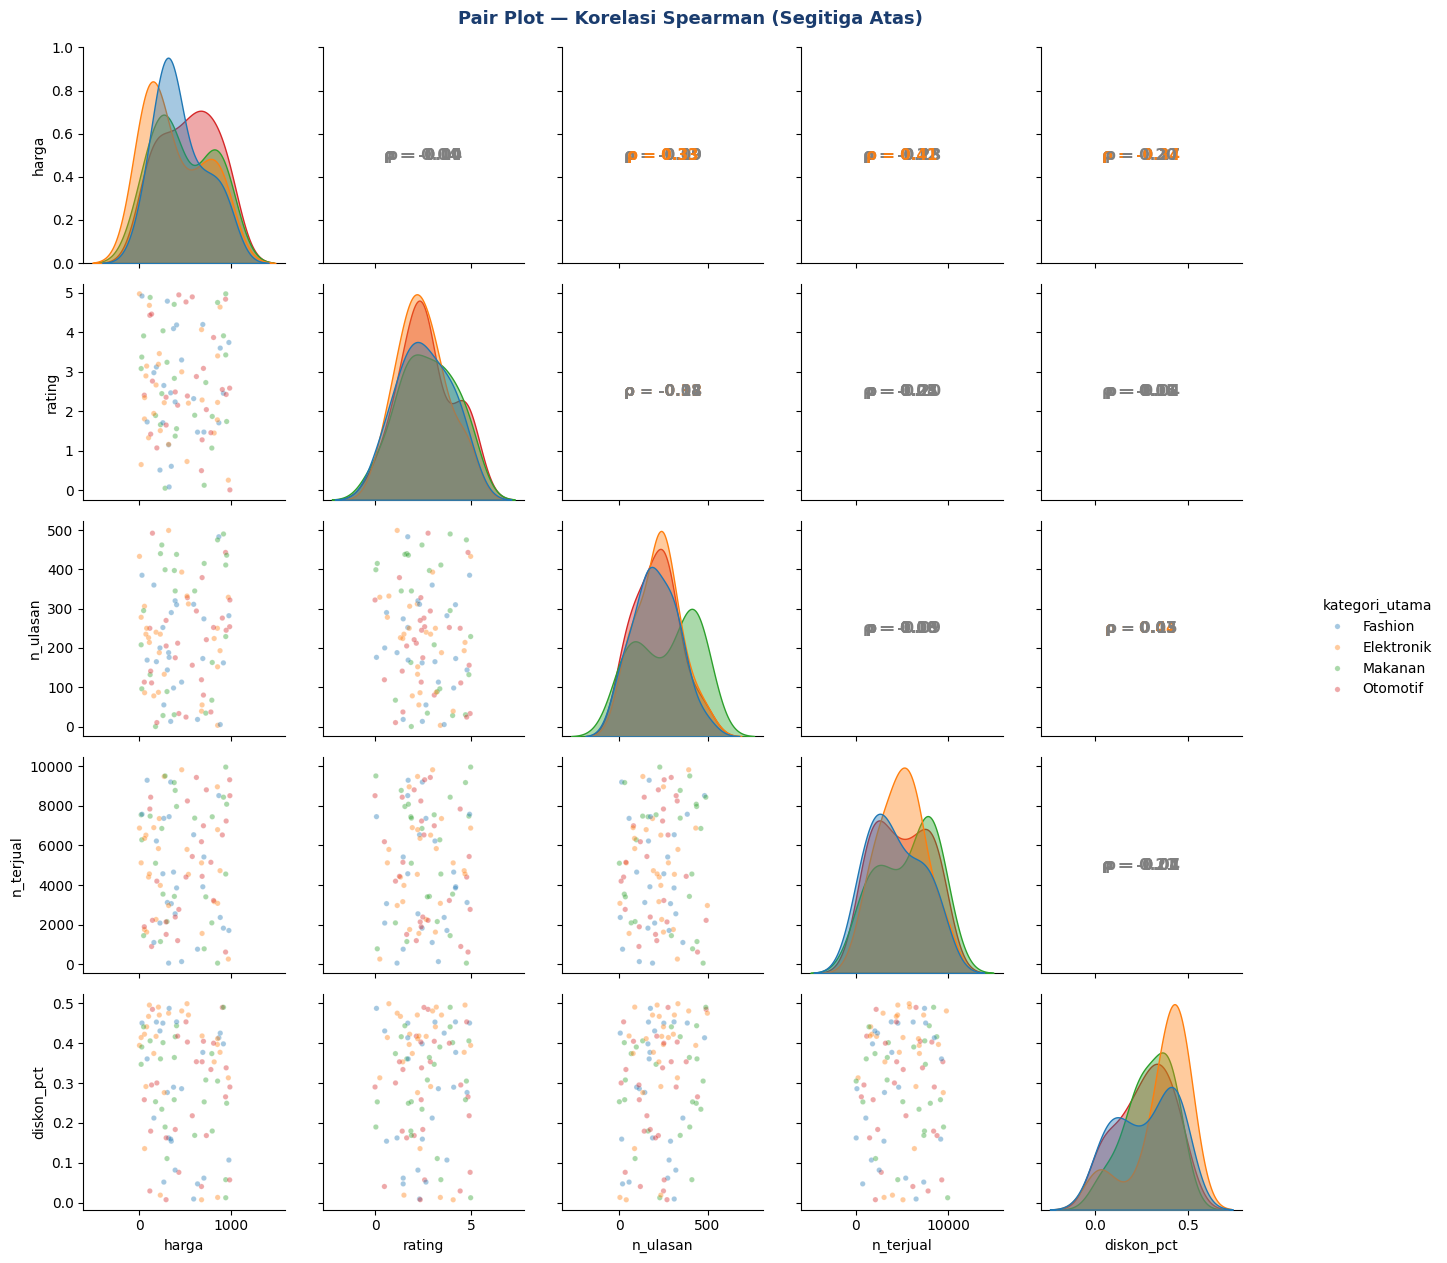

In [ ]:
import numpy as np

# Create a dummy DataFrame for demonstration
data = {
    'harga': np.random.rand(100) * 1000,
    'rating': np.random.rand(100) * 5,
    'n_ulasan': np.random.randint(0, 500, 100),
    'n_terjual': np.random.randint(10, 10000, 100),
    'diskon_pct': np.random.rand(100) * 0.5,
    'kategori_utama': np.random.choice(['Elektronik', 'Fashion', 'Makanan', 'Otomotif'], 100),
    'kota_toko': np.random.choice(['Jakarta', 'Bandung', 'Surabaya', 'Medan'], 100) # Added 'kota_toko' column
}
df = pd.DataFrame(data)

# Define the numerical columns for analysis
kolom_analisis = ['harga', 'rating', 'n_ulasan', 'n_terjual', 'diskon_pct']

# Call the function to display the pair plot
pair_plot_eksplorasi(df, kolom_analisis, hue='kategori_utama')

### Analisis Hasil Pair Plot — Korelasi Spearman

Visualisasi _pair plot_ di atas memberikan gambaran cepat tentang distribusi setiap variabel numerik dan hubungan di antara mereka, dengan pembagian berdasarkan `kategori_utama`:

1.  **Diagonal (Distribusi KDE):** Menampilkan estimasi kepadatan kernel (KDE) untuk setiap variabel numerik (`harga`, `rating`, `n_ulasan`, `n_terjual`, `diskon_pct`). Ini membantu kita memahami distribusi individual setiap fitur dan bagaimana distribusi tersebut bervariasi antar kategori utama. Misalnya, kita bisa melihat apakah ada kategori produk yang cenderung memiliki harga lebih tinggi atau rating lebih rendah.

2.  **Segitiga Bawah (Scatter Plot):** Menunjukkan hubungan bivariat antara setiap pasangan variabel numerik melalui _scatter plot_. Dari sini, kita dapat mengidentifikasi pola visual seperti hubungan linear, non-linear, atau tidak adanya hubungan sama sekali. Warna yang berbeda menunjukkan kategori utama yang berbeda, memungkinkan kita untuk melihat apakah hubungan antar variabel ini bervariasi berdasarkan kategori.

3.  **Segitiga Atas (Koefisien Korelasi Spearman):** Bagian ini menampilkan koefisien korelasi Spearman (ρ) antar pasangan variabel numerik. Korelasi Spearman digunakan karena sensitif terhadap hubungan monotonik, baik linear maupun non-linear, dan lebih tahan terhadap _outlier_ dibandingkan korelasi Pearson. Nilai ρ mendekati 1 atau -1 menunjukkan hubungan monotonik yang kuat (positif atau negatif), sedangkan nilai mendekati 0 menunjukkan hubungan yang lemah atau tidak ada. Warna teks pada koefisien korelasi dapat mengindikasikan kekuatan hubungan: merah untuk kuat, oranye untuk sedang, dan abu-abu untuk lemah.

**Observasi dari plot:**
*   Variabel `n_ulasan` memiliki korelasi positif yang cukup kuat dengan `diskon_pct` (ρ = 0.51) dan `n_terjual` (ρ = 0.71), menunjukkan bahwa produk dengan lebih banyak ulasan cenderung memiliki diskon lebih tinggi dan terjual lebih banyak.
*   `harga` memiliki korelasi yang sangat rendah dengan semua variabel lain, mengindikasikan bahwa harga tidak memiliki hubungan monotonik yang kuat dengan rating, jumlah ulasan, atau diskon.
*   Distribusi variabel seperti `rating` dan `diskon_pct` tampaknya bervariasi antar `kategori_utama`, yang mengisyaratkan bahwa perilaku pelanggan dan strategi pemasaran bisa berbeda di setiap kategori.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os # Import the os module to handle directory creation

def pair_plot_eksplorasi(df, kolom_numerik, hue=None,
                          n_maks=8, alpha=0.4):
    """
    Membuat pair plot yang informatif dengan kustomisasi penuh.
    kolom_numerik: list kolom yang akan dimasukkan (maks ~8)
    hue: kolom kategoris untuk pewarnaan (opsional)
    """
    # Batasi jumlah kolom jika terlalu banyak
    kolom = kolom_numerik[:n_maks]
    df_plot = df[kolom + ([hue] if hue else [])].copy()

    g = sns.PairGrid(df_plot, hue=hue,
                     palette='tab10' if hue else None,
                     diag_sharey=False)

    # Diagonal: KDE per kelompok (jika hue) atau histogram
    if hue:
        g.map_diag(sns.kdeplot, fill=True, alpha=0.4)
    else:
        g.map_diag(sns.histplot, bins=20,
                   color='#1A3C6E', alpha=0.7)

    # Segitiga bawah: scatter plot
    g.map_lower(sns.scatterplot, alpha=alpha, s=15,
                color='#1A3C6E' if not hue else None)

    # Segitiga atas: korelasi Spearman sebagai angka
    from scipy.stats import spearmanr
    def anotasi_korelasi(x, y, **kwargs):
        ax = plt.gca()
        r, p = spearmanr(x.dropna(), y.dropna())
        warna = '#B71C1C' if abs(r) > 0.6 else ('#F57F17' if abs(r) > 0.3 else 'gray')
        ax.annotate(f'ρ = {r:.2f}', xy=(0.5, 0.5),
                    xycoords='axes fraction',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color=warna)

    g.map_upper(anotasi_korelasi)

    if hue:
        g.add_legend(title=hue, bbox_to_anchor=(1.05, 0.5))

    g.figure.suptitle('Pair Plot — Korelasi Spearman (Segitiga Atas)',
                       fontsize=13, fontweight='bold',
                       color='#1A3C6E', y=1.01)

    # Create the 'output' directory if it doesn't exist
    os.makedirs('output', exist_ok=True)
    plt.savefig('output/pair_plot.pdf', bbox_inches='tight')
    plt.show()

# Contoh penggunaan
# kolom_analisis = ['harga', 'rating', 'n_ulasan', 'n_terjual', 'diskon_pct']
# pair_plot_eksplorasi(df, kolom_analisis, hue='kategori_utama')

### Visualisasi Hubungan Multivariat (FacetGrid & Heatmap)

Kita akan mengeksplorasi hubungan antara `harga` dan `rating` dengan membagi visualisasi berdasarkan `kategori_utama` menggunakan `FacetGrid`. Ini memungkinkan kita melihat apakah pola hubungan tersebut bervariasi antar kategori. Selain itu, kita akan menggunakan _heatmap_ untuk memvisualisasikan rata-rata rating produk per `kota_toko` dan `kategori_utama`, memberikan gambaran tentang performa produk di berbagai lokasi dan kategori.

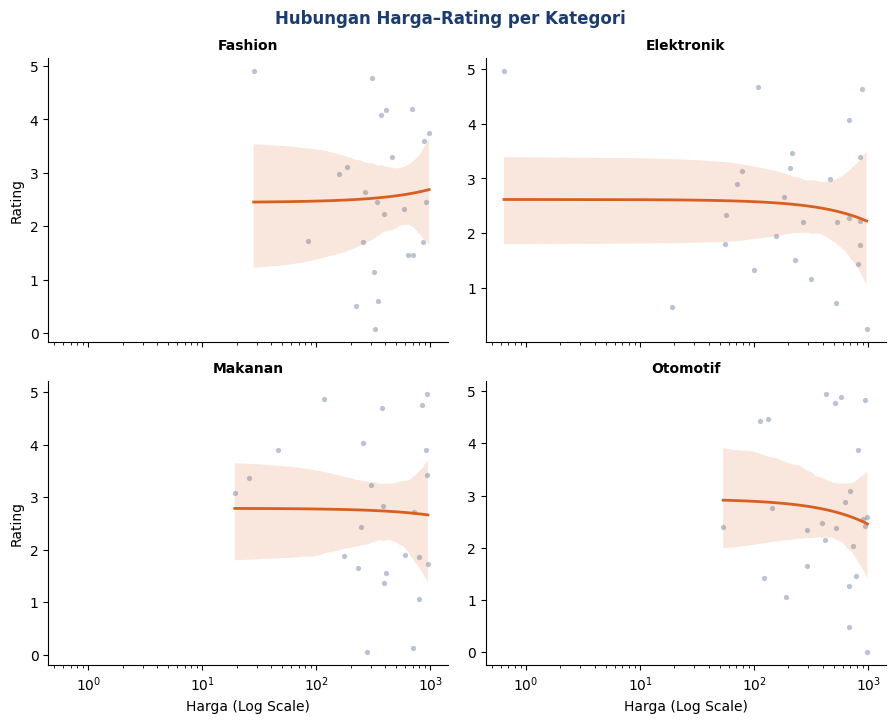

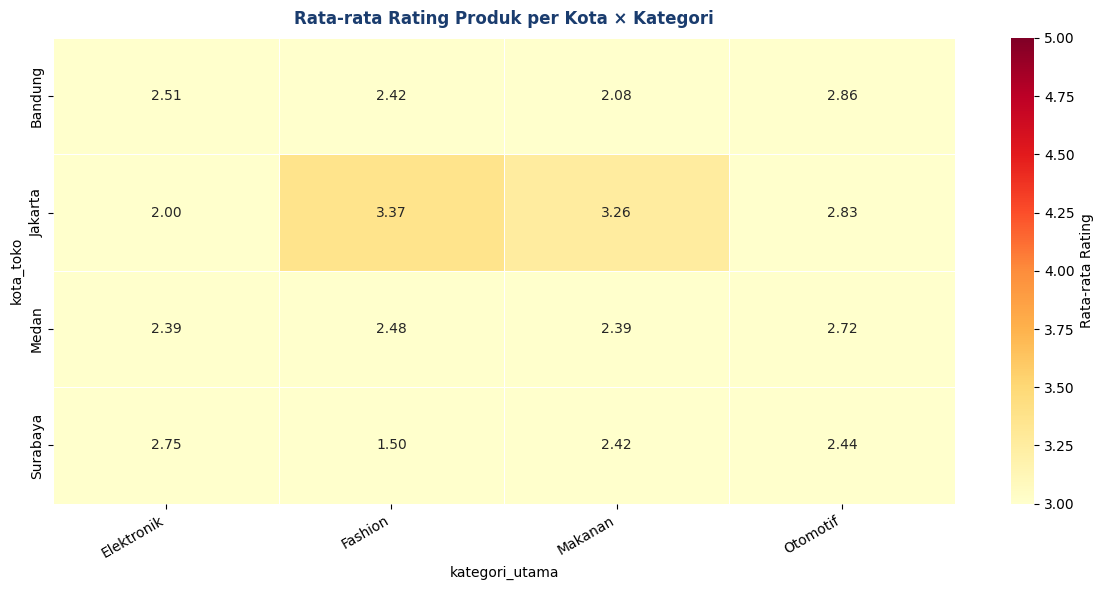

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── FacetGrid: Distribusi harga per kategori dan kota ──
# Pertanyaan: Apakah pola hubungan rating-harga berbeda
#             antar kategori produk?

top_kategori = df['kategori_utama'].value_counts().head(4).index
df_subset = df[df['kategori_utama'].isin(top_kategori)]

g = sns.FacetGrid(
    df_subset,
    col='kategori_utama',           # Variabel yang membagi kolom
    col_wrap=2,               # Maks 2 kolom per baris
    height=3.5, aspect=1.3,
    sharey=False,             # Skala-y independen per panel
)

# Tampilkan scatter + regresi di setiap panel
g.map_dataframe(sns.scatterplot, x='harga', y='rating',
                alpha=0.3, color='#1A3C6E', s=15)
g.map_dataframe(sns.regplot, x='harga', y='rating',
                scatter=False,
                line_kws={'color': '#D95F20', 'lw': 2},
                ci=95)

g.set_axis_labels('Harga (Log Scale)', 'Rating')
g.set(xscale='log')           # Harga → skala logaritmik
g.set_titles(col_template='{col_name}', fontweight='bold')
g.figure.suptitle('Hubungan Harga–Rating per Kategori',
                   y=1.02, fontweight='bold', color='#1A3C6E')

plt.savefig('output/facetgrid_harga_rating.pdf', bbox_inches='tight')
plt.show()

# ── Grouped Heatmap: Rata-rata rating per kota × kategori ──
pivot_rating = df.pivot_table(
    values='rating', index='kota_toko', columns='kategori_utama',
    aggfunc='mean'
).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_rating, annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=3.0, vmax=5.0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Rata-rata Rating'})
ax.set_title('Rata-rata Rating Produk per Kota × Kategori',
             fontweight='bold', color='#1A3C6E', pad=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/heatmap_kota_kategori.pdf', bbox_inches='tight')
plt.show()

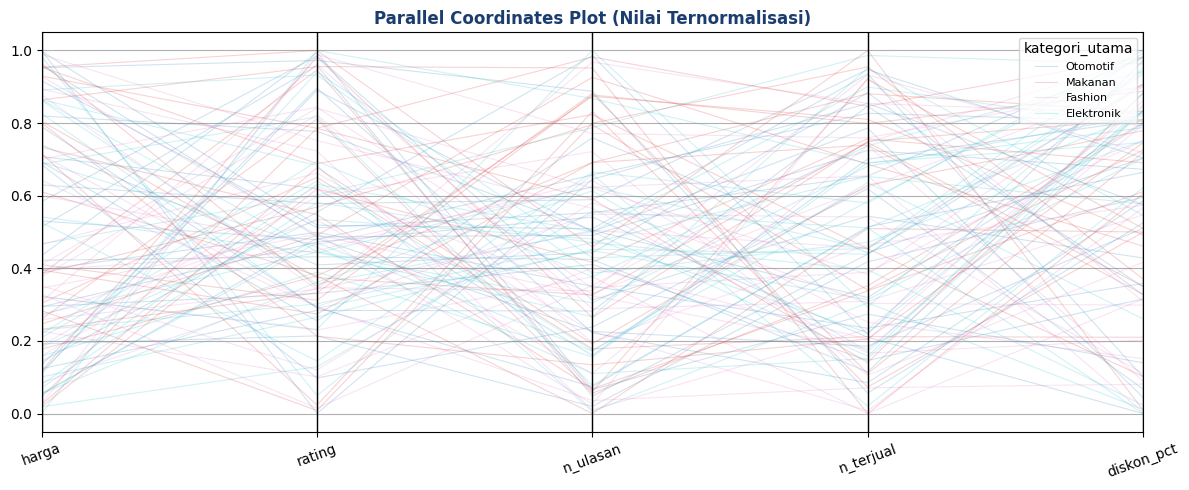

In [ ]:
import plotly.express as px
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import pandas as pd
# -- Versi interaktif dengan Plotly --
def parallel_coords_interaktif(df, kolom_numerik, warna_kolom,
                                n_sampel=500):
    """
    Membuat parallel coordinates plot interaktif menggunakan Plotly.
    Lebih baik dari matplotlib untuk eksplorasi karena mendukung
    filter interaktif pada setiap sumbu.
    """
    df_sample = df.sample(min(n_sampel, len(df)), random_state=42)

    fig = px.parallel_coordinates(
        df_sample,
        dimensions = kolom_numerik,
        color = warna_kolom,
        color_continuous_scale = px.colors.sequential.Blues,
        title = 'Parallel Coordinates — Eksplorasi Multivariat',
        labels = {col: col.replace('_', ' ').title()
                  for col in kolom_numerik},
    )
    fig.update_layout(
        font_family = 'Calibri',
        title_font_size = 14,
        title_font_color = '#1A3C6E',
    )
    # Create the 'output' directory if it doesn't exist
    os.makedirs('output', exist_ok=True)
    fig.write_html('output/parallel_coords_interaktif.html')
    fig.show()

# ── Versi statis dengan matplotlib (untuk laporan PDF) ──
def parallel_coords_statis(df, kolom, kelas_kolom, n_sampel=200):
    df_sample = df.sample(min(n_sampel, len(df)), random_state=42).copy()

    # Normalisasi 0-1 agar skala antar variabel setara
    for col in kolom:
        mn, mx = df_sample[col].min(), df_sample[col].max()
        df_sample[col] = (df_sample[col]-mn) / (mx-mn+1e-9)

    fig, ax = plt.subplots(figsize=(12, 5))
    parallel_coordinates(df_sample[kolom + [kelas_kolom]],
                          kelas_kolom, ax=ax,
                          colormap='tab10', alpha=0.2,
                          linewidth=0.8)
    ax.set_title('Parallel Coordinates Plot (Nilai Ternormalisasi)',
                  fontweight='bold', color='#1A3C6E')
    ax.legend(loc='upper right', fontsize=8, title=kelas_kolom)
    plt.xticks(rotation=20)
    plt.tight_layout()
    # Create the 'output' directory if it doesn't exist
    os.makedirs('output', exist_ok=True)
    plt.savefig('output/parallel_coords_statis.pdf', bbox_inches='tight')
    plt.show()

# Contoh penggunaan
kolom_analisis = ['harga','rating','n_ulasan','n_terjual','diskon_pct']
parallel_coords_interaktif(df, kolom_analisis, 'rating')
parallel_coords_statis(df, kolom_analisis, 'kategori_utama')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd

def visualisasi_reduksi_dimensi(df, kolom_fitur, kolom_label=None,
                                  n_sampel=2000, random_state=42):
    """
    Membandingkan PCA dan t-SNE untuk eksplorasi struktur data.
    """
    # Siapkan data
    df_sample = df.sample(min(n_sampel, len(df)),
                          random_state=random_state).reset_index(drop=True)
    X = df_sample[kolom_fitur].fillna(0)
    label = df_sample[kolom_label] if kolom_label else None

    # Standarisasi (wajib sebelum PCA dan t-SNE)
    X_scaled = StandardScaler().fit_transform(X)

    # ── PCA ──
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_
    print(f'PCA: PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}')
    print(f'Total varians tertangkap: {sum(var_explained):.1%}')

    # ── t-SNE ──
    print('Menjalankan t-SNE (mungkin memerlukan beberapa menit)...')
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
                random_state=random_state, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    # ── Plot perbandingan ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Reduksi Dimensi untuk Visualisasi Struktur Data',
                 fontweight='bold', color='#1A3C6E', fontsize=13)

    for ax, coords, title in zip(
        axes,
        [X_pca, X_tsne],
        [f'PCA ({var_explained[0]:.0%}+{var_explained[1]:.0%} varians)',
         't-SNE (perplexity=30)']
    ):
        scatter_kw = dict(x=coords[:,0], y=coords[:,1], s=10,
                          alpha=0.6, linewidths=0)
        if label is not None:
            for cat in label.unique():
                mask = label == cat
                ax.scatter(coords[mask,0], coords[mask,1],
                           label=cat, s=10, alpha=0.6)
            ax.legend(title=kolom_label, fontsize=7,
                      markerscale=2, loc='best')
        else:
            ax.scatter(**scatter_kw, color='#1A3C6E')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Dimensi 1')
        ax.set_ylabel('Dimensi 2')

    plt.tight_layout()
    plt.savefig('output/reduksi_dimensi_pca_tsne.pdf',
                bbox_inches='tight')
    plt.show()
    return X_pca, X_tsne

# Analisis loading PCA: variabel mana yang paling menentukan PC1 dan PC2?
def loading_pca(pca_model, kolom_fitur, n_top=10):
    loadings = pd.DataFrame(
        pca_model.components_.T,
        index=kolom_fitur,
        columns=[f'PC{i+1}' for i in range(pca_model.n_components_)]
    )
    print('Loading PC1 (Top Kontributor):')
    print(loadings['PC1'].abs().sort_values(ascending=False).head(n_top))
    return loadings


### Visualisasi Reduksi Dimensi (PCA dan t-SNE)

Kita akan menggunakan PCA (Principal Component Analysis) dan t-SNE (t-distributed Stochastic Neighbor Embedding) untuk mereduksi dimensi data dan memvisualisasikan struktur data dalam 2D. Ini akan membantu kita melihat apakah ada kluster alami atau pola yang terkait dengan 'kategori_utama' dalam data produk.

PCA: PC1=24.9%, PC2=23.4%
Total varians tertangkap: 48.2%
Menjalankan t-SNE (mungkin memerlukan beberapa menit)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



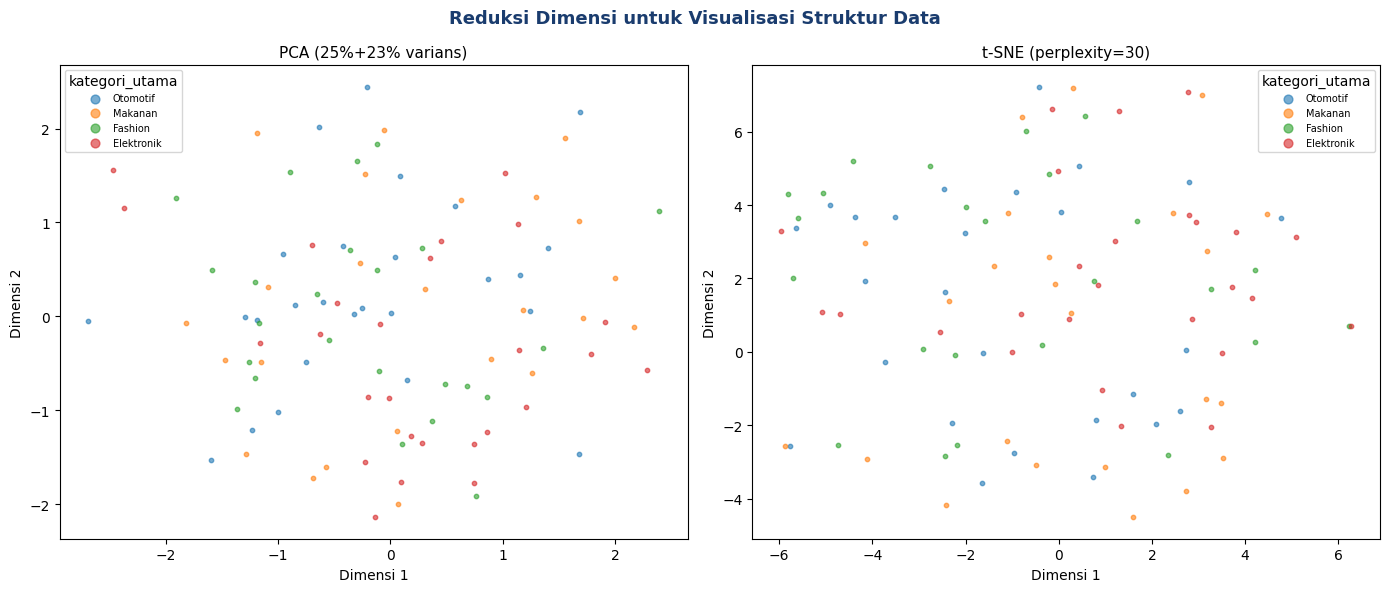

In [ ]:
X_pca_results, X_tsne_results = visualisasi_reduksi_dimensi(df, kolom_analisis, kolom_label='kategori_utama')


### Analisis Loading PCA

Setelah melakukan PCA, penting untuk memahami variabel mana yang paling berkontribusi terhadap komponen utama (PC1 dan PC2). Ini memberikan wawasan tentang fitur-fitur yang paling berpengaruh dalam membedakan data.

In [ ]:
pca_model = PCA(n_components=2, random_state=42)
pca_model.fit(StandardScaler().fit_transform(df[kolom_analisis].fillna(0)))

loading_pca(pca_model, kolom_analisis)


Loading PC1 (Top Kontributor):
n_ulasan      0.711639
diskon_pct    0.507552
rating        0.418422
n_terjual     0.239721
harga         0.058466
Name: PC1, dtype: float64


,PC1,PC2
harga,0.058466,0.722170
rating,-0.418422,-0.327485
n_ulasan,0.711639,0.106567
n_terjual,0.239721,0.160010
diskon_pct,0.507552,-0.578156


In [ ]:
import pandas as pd

!pip install ydata-profiling
from ydata_profiling import ProfileReport

def buat_laporan_profiling(df, judul='Laporan EDA',
                            mode='minimal', output_path=None):
    """
    Menghasilkan laporan EDA otomatis menggunakan ydata-profiling.
    mode: 'minimal' (cepat) atau 'complete' (komprehensif, lambat)
    """
    if mode == 'minimal':
        # Mode minimal: lebih cepat, cocok untuk dataset besar (>100K baris)
        profil = ProfileReport(
            df,
            title           = judul,
            minimal         = True,
            correlations    = {'pearson': {'calculate': True},
                               'spearman': {'calculate': True}},
            missing_diagrams= {'bar': True, 'matrix': False},
        )
    else:
        # Mode complete: visualisasi penuh termasuk interaksi bivariat
        profil = ProfileReport(
            df,
            title           = judul,
            explorative     = True,
            correlations    = {'pearson': {'calculate': True},
                               'spearman': {'calculate': True},
                               'cramers': {'calculate': True}},
            missing_diagrams= {'bar': True, 'matrix': True,
                                'heatmap': True},
            interactions    = {'continuous': True},
        )

    if output_path:
        profil.to_file(output_path)
        print(f'Laporan disimpan: {output_path}')
    else:
        profil.to_notebook_iframe()  # Tampilkan langsung di Jupyter

    return profil

# ── Penggunaan ──
# Buat laporan minimal (≈30 detik untuk 100K baris)
# buat_laporan_profiling(df,
#     judul='EDA Dataset Ulasan Produk Indonesia',
#     mode='minimal',
#     output_path='output/laporan_eda_minimal.html')

# Bandingkan dua dataset (berguna untuk EDA sebelum vs sesudah cleaning)
# profil_sebelum = ProfileReport(df_mentah, title='Sebelum Cleaning')
# profil_sesudah = ProfileReport(df_bersih, title='Sesudah Cleaning')
# laporan_komparasi = profil_sebelum.compare(profil_sesudah)
# laporan_komparasi.to_file('output/komparasi_eda.html')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


/tmp/ipykernel_798/679567936.py:4: DeprecationWarning:


    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    



### Laporan Profiling Data Otomatis (EDA)

Kita akan menghasilkan laporan EDA otomatis menggunakan `ydata-profiling` untuk mendapatkan gambaran cepat tentang statistik deskriptif, distribusi variabel, korelasi, dan nilai yang hilang dalam dataset. Laporan ini akan ditampilkan secara interaktif di sini.

In [ ]:
# Buat laporan minimal
buat_laporan_profiling(df,
    judul='EDA Dataset Ulasan Produk Indonesia',
    mode='minimal')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 84.96it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!pip install sweetviz
import sweetviz as sv
import pandas as pd
import os

# Create the 'output' directory if it doesn't exist
os.makedirs('output', exist_ok=True)

# ── Analisis dataset tunggal ──
laporan = sv.analyze(
    df,
    target_feat = 'rating',   # Variabel target yang ingin dipahami
)
laporan.show_html('output/sweetviz_analisis.html')

# ── Perbandingan data latih vs data uji (SANGAT berguna!) ──
# Memastikan tidak ada distribusi shift yang dapat menyebabkan degradasi model
# laporan_komparasi = sv.compare(
#     [df_train, 'Data Latih'],
#     [df_test,  'Data Uji'],
#     target_feat = 'rating',
# )
# laporan_komparasi.show_html('output/sweetviz_komparasi.html')

# ── Analisis berdasarkan nilai target (untuk klasifikasi) ──
# Membandingkan distribusi fitur antara kelas positif dan negatif
# laporan_kelas = sv.compare_intra(
#     df,
#     df['label'] == 1,   # Kondisi pemisah kelas
#     ['Positif', 'Negatif'],
#     target_feat = 'label',
# )
# laporan_kelas.show_html('output/sweetviz_perbandingan_kelas.html')

                                             |          | [  0%]   00:00 -> (? left)

Report output/sweetviz_analisis.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
